In [1]:
import re
import pandas as pd
import nltk
from nltk.tokenize import RegexpTokenizer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
nltk.download('averaged_perceptron_tagger_eng')
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report,  roc_curve, auc
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure NLTK resources are downloaded
nltk.download('wordnet')
nltk.download('omw-1.4')



[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\amith\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\amith\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\amith\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [2]:
DATASET_COLUMNS=['target','ids','date','flag','user','text']
DATASET_ENCODING = "ISO-8859-1"
df = pd.read_csv('training.1600000.processed.noemoticon.csv', encoding=DATASET_ENCODING, names=DATASET_COLUMNS)


In [3]:
df

,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
...,...,...,...,...,...,...
1599995,4,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
1599996,4,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
1599997,4,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
1599998,4,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...


In [4]:
def clean_text(text):
    stopwordlist = [
        'a', 'about', 'above', 'after', 'again', 'ain', 'all', 'am', 'an',
        'and', 'any', 'are', 'as', 'at', 'be', 'because', 'been', 'before',
        'being', 'below', 'between', 'both', 'by', 'can', 'd', 'did', 'do',
        'does', 'doing', 'down', 'during', 'each', 'few', 'for', 'from',
        'further', 'had', 'has', 'have', 'having', 'he', 'her', 'here',
        'hers', 'herself', 'him', 'himself', 'his', 'how', 'i', 'if', 'in',
        'into', 'is', 'it', "it's", 'its', 'itself', 'just', 'll', 'm', 'ma',
        'me', 'more', 'most', 'my', 'myself', 'needn', 'no', 'nor', 'now',
        'o', 'of', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves',
        'out', 'own', 're', 's', 'same', 'she', "shes", 'should', "shouldve", 'so', 'some', 'such',
        't', 'than', 'that', "thatll", 'the', 'their', 'theirs', 'them',
        'themselves', 'then', 'there', 'these', 'they', 'this', 'those',
        'through', 'to', 'too', 'under', 'until', 'up', 've', 'very', 'was',
        'we', 'were', 'what', 'when', 'where', 'which', 'while', 'who', 'whom',
        'why', 'will', 'with', 'won', 'y', 'you', "youd", "youll", "youre",
        "youve", 'your', 'yours', 'yourself', 'yourselves'
    ]

    # Function to get NLTK POS tag to WordNet POS tag
    def get_wordnet_pos(treebank_tag):
        if treebank_tag.startswith('J'):
            return wordnet.ADJ
        elif treebank_tag.startswith('V'):
            return wordnet.VERB
        elif treebank_tag.startswith('N'):
            return wordnet.NOUN
        elif treebank_tag.startswith('R'):
            return wordnet.ADV
        else:
            return wordnet.NOUN
    
    # Convert to lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'((www\.[^\s]+)|(https?://[^\s]+))', ' ', text)
    # Replace @mentions with 'USER'
    text = re.sub(r'@[\S]+', 'USER', text)
    # Remove hashtags but keep the text
    text = re.sub(r'#(\S+)', r'\1', text)
    # Remove digits
    text = re.sub(r'\d+', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text)
    # Strip leading and trailing whitespace
    text = text.strip()
    # Remove stopwords
    text = " ".join([word for word in text.split() if word not in stopwordlist])
    # Tokenize text
    tokenizer = RegexpTokenizer(r'\w+|[^\w\s]')
    tokens = tokenizer.tokenize(text)

    # POS tagging
    pos_tags = nltk.pos_tag(tokens)

    # Lemmatize each token with the appropriate POS tag
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(token, get_wordnet_pos(tag)) for token, tag in pos_tags]
    
    return " ".join(lemmatized_tokens)

In [5]:

# Replace target values
df['target'] = df['target'].replace(4, 1)

# Preprocess the text data
df['text'] = df['text'].apply(clean_text)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['target'], test_size=0.2, random_state=42)

In [7]:
#term frequency-inverse document frequency (TF-IDF) vectorization
vectorizer= TfidfVectorizer(max_features=500000, ngram_range=(1, 2))
# Fit the vectorizer on the training data and transform both training and test data
X_train_vect=vectorizer.fit_transform(X_train)
#Transform the test data using the fitted vectorizer
X_test_vect=vectorizer.transform(X_test)

In [8]:
def evaluate_model(model):# Evaluate the model using confusion matrix and classification report
    model.fit(X_train_vect, y_train)# Fit the model on the training data
    y_pred = model.predict(X_test_vect)# Predict on the test data
    print(classification_report(y_test, y_pred))# Print classification report

In [9]:
lr_model=LogisticRegression(C=2,max_iter=100,n_jobs=-1)# Fit the model on the training data 
evaluate_model(lr_model)# Predict on the test data

              precision    recall  f1-score   support

           0       0.81      0.79      0.80    159494
           1       0.80      0.82      0.81    160506

    accuracy                           0.80    320000
   macro avg       0.80      0.80      0.80    320000
weighted avg       0.80      0.80      0.80    320000



In [10]:
example_text =  "Just a test tweet to check the model's prediction."
clean_example_text = clean_text(example_text)
example_vector = vectorizer.transform([clean_example_text])
prediction = lr_model.predict(example_vector)
print(f"Prediction for '{example_text}': {'Positive' if prediction[0] == 1 else 'Negative'}")

Prediction for 'Just a test tweet to check the model's prediction.': Positive


In [11]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model):
    model.fit(X_train_vect, y_train)
    y_pred = model.predict(X_test_vect)
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()


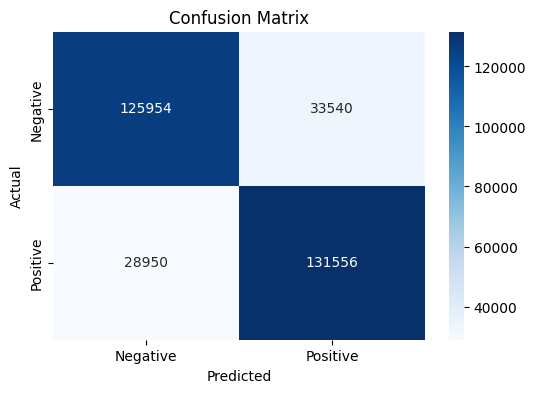

In [12]:
plot_confusion_matrix(lr_model)


In [13]:
import joblib

# Save the trained model
joblib.dump(lr_model, 'sentiment_logistic_model.pkl')

# Save the TF-IDF vectorizer
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')


['tfidf_vectorizer.pkl']

In [14]:
# Load the model
loaded_model = joblib.load('sentiment_logistic_model.pkl')

# Load the vectorizer
loaded_vectorizer = joblib.load('tfidf_vectorizer.pkl')


In [15]:
def predict_sentiment(text, model, vectorizer):
    cleaned = clean_text(text)
    vect = vectorizer.transform([cleaned])
    pred = model.predict(vect)
    return "Positive" if pred[0] == 1 else "Negative"

# Example usage:
print(predict_sentiment("I love this!", loaded_model, loaded_vectorizer))


Positive
